In [2]:
from matplotlib.pyplot import cm
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy import constants as cst
import sys, os, git
import warnings
warnings.filterwarnings("ignore")

In [3]:
current_path = os.getcwd()
git_repo = git.Repo(current_path, search_parent_directories=True)
git_path = git_repo.git.rev_parse("--show-toplevel")
path_figures = current_path[len(git_path):] + '/'
path_in_folder = current_path[len(git_path)+1:]

In [4]:
sys.path.append(git_path + "/.submodules/pyplot-perso")
from plttools import PltTools

In [5]:
cmap_cool = cm.cool
cmap_dark_blue_to_cyan = LinearSegmentedColormap.from_list('dark_blue_to_cyan', ['#1D11CB', cmap_cool(0.0)])
cmap_viridis = cm.viridis      # excellent general-purpose
cmap_cividis = cm.cividis      # best for accessibility (colorblind-safe)
cmap_turbo   = cm.turbo        # very high contrast, vivid range
cmap_plasma  = cm.plasma       # strong contrast, warm highlights
cmap_inferno = cm.inferno      # dark-to-bright, great on dark BG
cmap_magma   = cm.magma        # smoother dark-background readability

cmap_cool = cm.cool
cmap_cyan_to_green_blue = LinearSegmentedColormap.from_list(
    "cyan_to_green_blue", ["#0f55eb", "#00FFFF", "#00FA9A"])

  Pixels: width = 723.9 x height = 682.9
  Aspect ratio: 1.0601
  Pixels: width = 723.9 x height = 682.9
  Aspect ratio: 1.0601


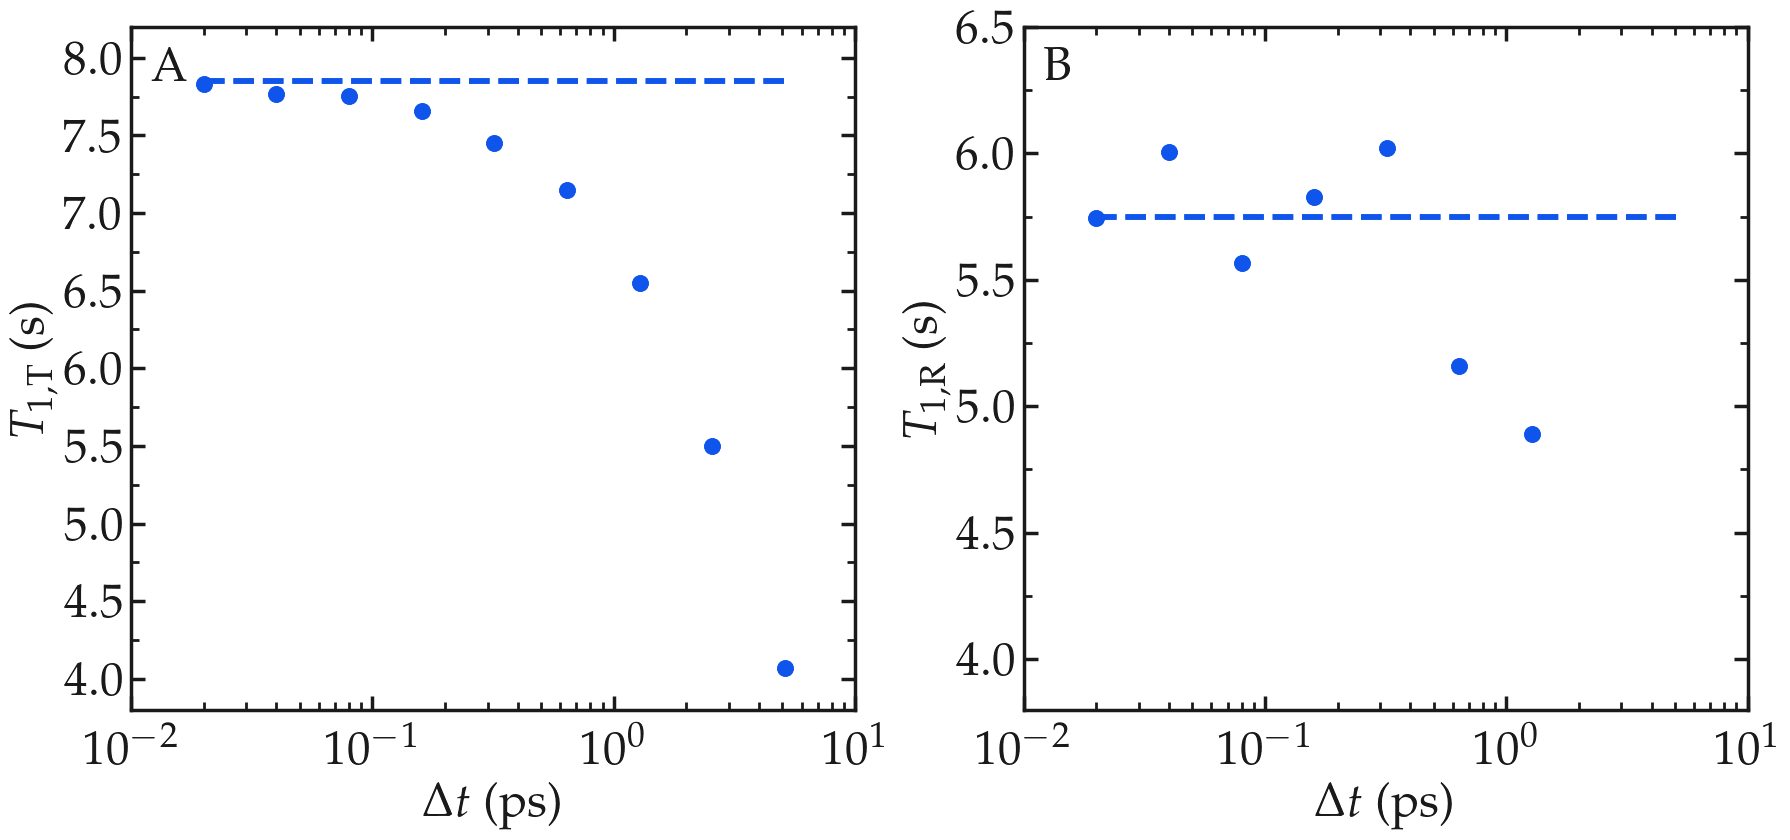

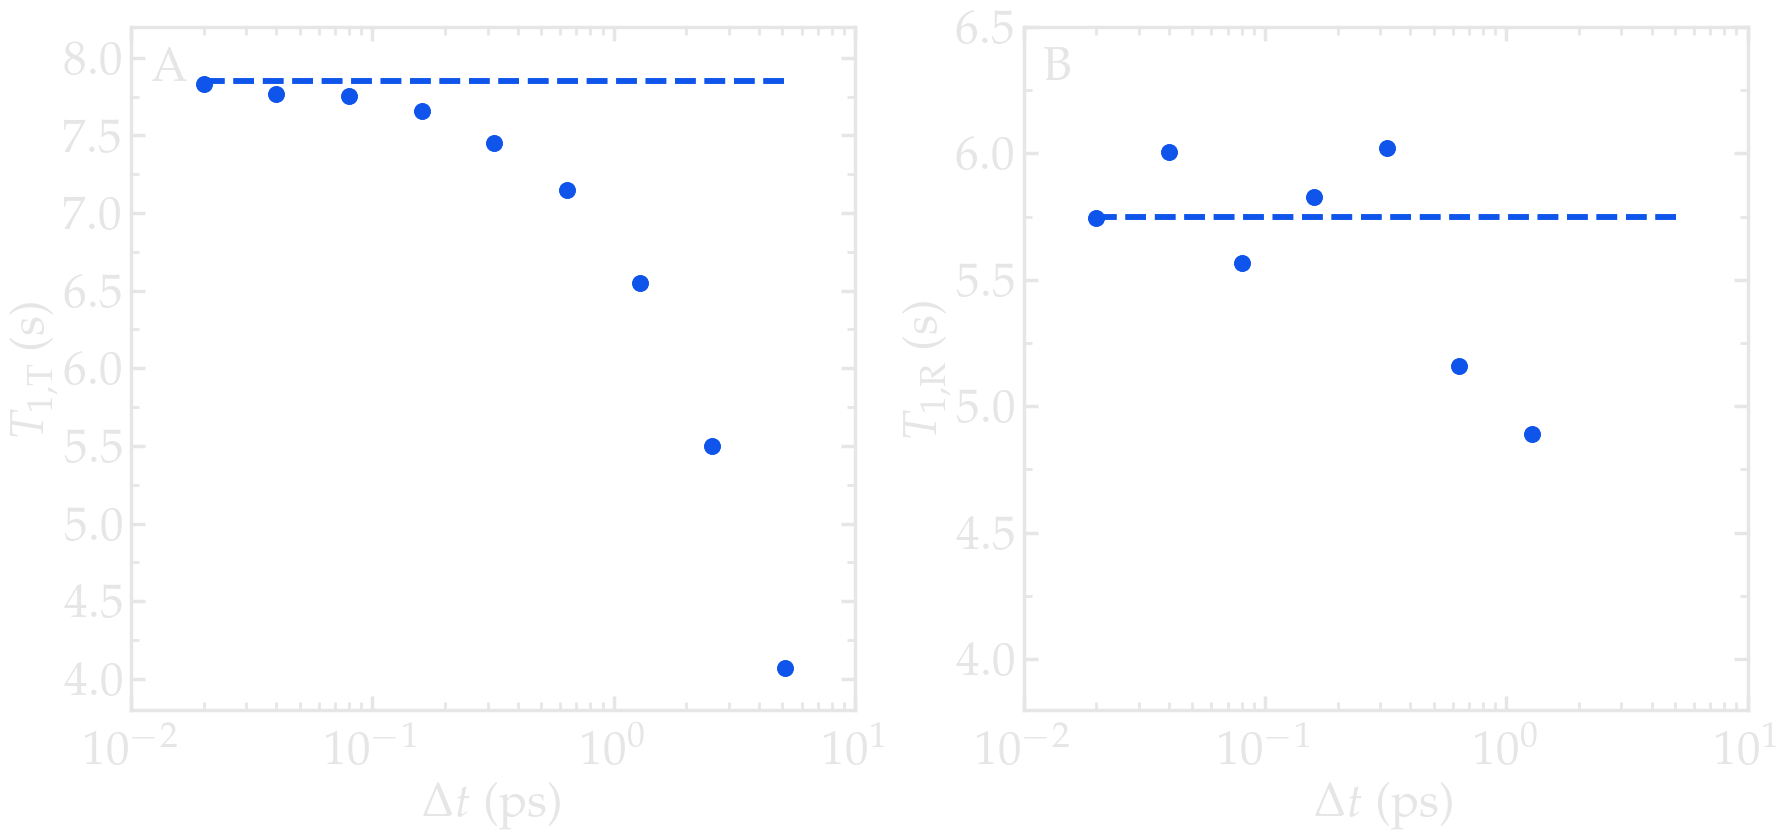

In [20]:
n = 500
type = "full"

for dark_mode in [False, True]:

    myplt = PltTools()
    myplt.prepare_figure(fig_size = (18, 8.5), dark_mode = dark_mode,
                         transparency = True, use_serif=True, n_colone = 2)
    
    # Panel 1
    colors = cmap_cyan_to_green_blue(np.linspace(0, 1, 3))

    myplt.add_panel()

    dump, R1 = np.loadtxt("water-dump/R10_inter_vs_dump.dat").T
    myplt.add_plot(x = dump, y = 1/R1, type = "semilogx", linewidth_data = 3,
                marker = "o", data_color = colors[0][:3],
                markersize = 12) # , data_label = r'TIP4P')
    myplt.add_plot(x = dump, y = 1/R1*0+7.85, type = "semilogx", linewidth_data = 3,
            marker = "--", data_color = colors[0][:3],
            markersize = 12) # , data_label = r'TIP4P')
    
    myplt.complete_panel(xlabel = r'$\Delta t$ ($\mathrm{ps}$)', ylabel = r'$T_\mathrm{1, T}$ (s)',
                         xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(0.01, 10), y_boundaries=(3.8, 8.2))

    # Panel 1
    colors = cmap_cyan_to_green_blue(np.linspace(0, 1, 3))

    myplt.add_panel()

    dump, R1 = np.loadtxt("water-dump/R10_intra_vs_dump.dat").T
    myplt.add_plot(x = dump, y = 1/R1, type = "semilogx", linewidth_data = 3,
                marker = "o", data_color = colors[0][:3],
                markersize = 12) # , data_label = r'TIP4P')
    myplt.add_plot(x = dump, y = 1/R1*0+5.75, type = "semilogx", linewidth_data = 3,
            marker = "--", data_color = colors[0][:3],
            markersize = 12) # , data_label = r'TIP4P')
    
    myplt.complete_panel(xlabel = r'$\Delta t$ ($\mathrm{ps}$)', ylabel = r'$T_\mathrm{1, R}$ (s)',
                         xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(0.01, 10), y_boundaries=(3.8, 6.5))

    myplt.add_subplotlabels(type_label_panel = "A")
    myplt.save_figure(filename = "water-dump", saving_path = git_path+path_figures)